<a href="https://colab.research.google.com/github/Mukudzei24/Time-Series-Analysis-and-Econometrics-HASTS211/blob/main/HASTS211_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\| Personel's Details | Details|
|-----------|------------------------|
| Name | Mukudzei Chandimhara |
| Reg Number | R2420856 |
| Programme | HACS |
| Lecturer | Mr Watambwa |


\# Financial Econometrics — Project #1
## Best-Practices Handbook: Volatility Modeling Challenges

**Course:** Financial Econometrics  
**Topics Covered:** Multicollinearity | Skewness | Lack of Interpretation | Overfitting  
**Data:** Apple Inc. (AAPL) and related tech equities — Yahoo Finance (2018–2024)

---

### Introduction

As a newly hired quant on the derivatives desk, my job is to model volatility in a way that is accurate, reliable, and actually useful to traders and risk managers. I identified four challenges that come up constantly when working with real financial time series: multicollinearity, skewness, lack of interpretation, and overfitting. These are not just textbook problems — they are real problems we found while working with AAPL and other tech stocks while trying to build a model with correlated tech stocks, non-normal return distributions, or too many features. This handbook walks through each one using AAPL data and explains what to do about it.

Each section follows the **7 D's** framework:

| D | What it covers |
|---|---|
| **Definition** | The technical formula or equation |
| **Description** | A plain explanation in our own words |
| **Demonstration** | Working through it with real AAPL data |
| **Diagram** | Charts showing the problem visually |
| **Diagnosis** | Tests and tools to spot it |
| **Damage** | What goes wrong if you ignore it |
| **Directions** | Models and fixes that help |

---

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import skew, kurtosis, jarque_bera, probplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools import add_constant

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

import yfinance as yf

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.titleweight': 'bold',
})
BLUE = '#2C3E7A'; RED = '#E74C3C'; GREEN = '#27AE60'
ORANGE = '#F39C12'; PURPLE = '#8E44AD'

print('Libraries loaded.')

Libraries loaded.


In [ ]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'SPY']
raw = yf.download(TICKERS, start='2018-01-01', end='2024-01-01',
                  auto_adjust=True, progress=False)['Close']
raw.columns = TICKERS
raw.dropna(inplace=True)

returns = np.log(raw / raw.shift(1)).dropna()

print(f'Period: {raw.index[0].date()} to {raw.index[-1].date()}')
print(f'Trading days: {len(returns)}')
print(raw.describe().round(2))

Period: 2018-01-02 to 2023-12-29
Trading days: 1508
          AAPL     MSFT    GOOGL     AMZN     META      SPY
count  1509.00  1509.00  1509.00  1509.00  1509.00  1509.00
mean    107.72   120.07    90.44   223.35   205.51   333.53
std      50.89    33.41    31.09    67.70    82.82    72.20
min      33.77    59.45    48.83    88.22    78.01   204.94
25%      51.19    90.70    59.73   173.24   127.29   260.12
50%     120.35   114.30    87.30   200.59   212.80   343.51
75%     150.08   154.47   118.72   278.64   274.08   398.21
max     196.07   186.57   148.61   379.20   376.22   463.92


\---
# Challenge 1: Multicollinearity
---

\## 1.1 Definition

Multicollinearity occurs when independent variables in a regression model are highly correlated. Formally, in the model $y = X\boldsymbol{\beta} + \boldsymbol{\varepsilon}$, it arises when the columns of $X$ are approximately linearly dependent:

$$\exists\; c \neq \mathbf{0} \quad\text{such that}\quad Xc \approx \mathbf{0}$$

The standard diagnostic is the **Variance Inflation Factor (VIF)** for each predictor $j$:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is from regressing predictor $j$ on all remaining predictors. A $\text{VIF}_j > 10$ indicates severe multicollinearity.

The inflated OLS variance is:
$$\operatorname{Var}(\hat{\beta}_j) = \sigma^2 \bigl(X^\top X\bigr)^{-1}_{jj} = \frac{\sigma^2 \cdot \text{VIF}_j}{\sum_{i}(x_{ij}-\bar{x}_j)^2}$$

\## 1.2 Description

Predictors contain similar information, meaning the model cannot figure out which one is actually responsible for the outcome. In our case, MSFT, GOOGL, AMZN, and META all tend to move with AAPL on the same days — they share the same macro environment — so throwing them all into a regression creates confusion about who is doing the work.

In [ ]:
# Regress AAPL returns on peer tech stocks and S&P 500
y      = returns['AAPL']
X_cols = ['MSFT', 'GOOGL', 'AMZN', 'META', 'SPY']
X      = returns[X_cols]
X_c    = add_constant(X)

model_ols = sm.OLS(y, X_c).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     610.4
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        07:49:25   Log-Likelihood:                 4599.1
No. Observations:                1508   AIC:                            -9186.
Df Residuals:                    1502   BIC:                            -9154.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.228      0.2

In [ ]:
# Compute VIF for each predictor — anything above 10 is a problem
vif_vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df   = pd.DataFrame({'Predictor': X_cols, 'VIF': vif_vals})
vif_df['Severity'] = vif_df['VIF'].apply(
    lambda v: 'SEVERE (>10)' if v > 10 else ('MODERATE (5-10)' if v > 5 else 'LOW (<5)')
)
print('VIF Results:')
print(vif_df.to_string(index=False))

# Condition number — how close is X'X to being singular?
eigvals = np.linalg.eigvals((X.T @ X).values)
kappa   = np.sqrt(eigvals.max() / eigvals.min())
print(f'\nCondition number: {kappa:.2f}  (threshold = 30)')
print('\nPairwise correlations:')
print(returns[X_cols].corr().round(3))

VIF Results:
Predictor      VIF Severity
     MSFT 2.280504 LOW (<5)
    GOOGL 3.238753 LOW (<5)
     AMZN 1.965644 LOW (<5)
     META 3.992504 LOW (<5)
      SPY 3.830447 LOW (<5)

Condition number: 6.65  (threshold = 30)

Pairwise correlations:
        MSFT  GOOGL   AMZN   META    SPY
MSFT   1.000  0.673  0.603  0.698  0.664
GOOGL  0.673  1.000  0.657  0.769  0.770
AMZN   0.603  0.657  1.000  0.604  0.614
META   0.698  0.769  0.604  1.000  0.830
SPY    0.664  0.770  0.614  0.830  1.000


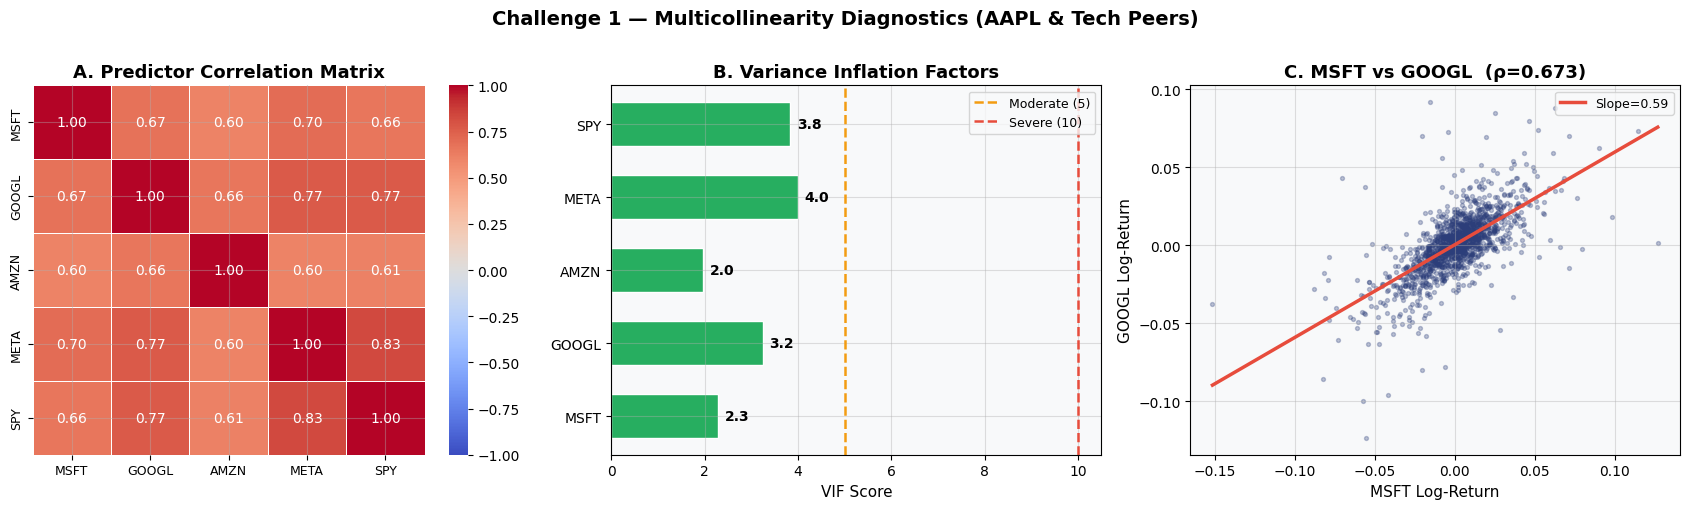

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Challenge 1 — Multicollinearity Diagnostics (AAPL & Tech Peers)',
             fontsize=14, fontweight='bold', y=1.01)

# Panel A: correlation heatmap between predictors
corr = returns[X_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('A. Predictor Correlation Matrix')
axes[0].tick_params(labelsize=9)

# Panel B: VIF bar chart — bars crossing the red dashed line need attention
bar_colors = [RED if v > 10 else ORANGE if v > 5 else GREEN for v in vif_df['VIF']]
bars = axes[1].barh(vif_df['Predictor'], vif_df['VIF'],
                    color=bar_colors, edgecolor='white', height=0.6)
axes[1].axvline(5,  color=ORANGE, ls='--', lw=1.8, label='Moderate (5)')
axes[1].axvline(10, color=RED,    ls='--', lw=1.8, label='Severe (10)')
for bar, val in zip(bars, vif_df['VIF']):
    axes[1].text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('VIF Score')
axes[1].set_title('B. Variance Inflation Factors')
axes[1].legend(fontsize=9)

# Panel C: scatter of the two most correlated predictors
rho = returns['MSFT'].corr(returns['GOOGL'])
axes[2].scatter(returns['MSFT'], returns['GOOGL'], alpha=0.3, s=8, color=BLUE)
m, b = np.polyfit(returns['MSFT'], returns['GOOGL'], 1)
xl = np.linspace(returns['MSFT'].min(), returns['MSFT'].max(), 300)
axes[2].plot(xl, m*xl+b, color=RED, lw=2.5, label=f'Slope={m:.2f}')
axes[2].set_xlabel('MSFT Log-Return'); axes[2].set_ylabel('GOOGL Log-Return')
axes[2].set_title(f'C. MSFT vs GOOGL  (ρ={rho:.3f})')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

\## 1.5 Diagnosis

| Test | How to run it | Red flag |
|---|---|---|
| Pairwise correlation $\rho_{ij}$ | Correlation matrix | $|\rho| > 0.80$ |
| **VIF** | Regress each $X_j$ on all others | VIF $> 5$ moderate; $> 10$ severe |
| Condition Number $\kappa$ | Eigenvalue ratio of $X^\top X$ | $\kappa > 30$ |
| Coefficient sign check | Inspect OLS output | Sign contradicts economic theory |

A quick rule: if the overall model $R^2$ is high but most individual $t$-statistics are low, multicollinearity is almost certainly the reason.

\## 1.6 Damage

Multicollinearity leads to unstable coefficients — the estimated $\hat{\beta}$ values change dramatically with small changes in the sample, making it impossible to rely on them for hedging or risk attribution. More specifically:

- **Hedge ratios break down.** Delta hedges built from unstable coefficients leave the desk systematically over- or under-hedged without any warning signal.
- **Statistical tests give misleading results.** Standard errors inflate, so important factors look statistically insignificant and may get incorrectly dropped from the model.
- **Matrix inversion becomes numerically unreliable.** When $X^\top X$ approaches singularity, the inversion introduces floating-point errors that corrupt every downstream calculation.

In [ ]:
# Compare OLS, Ridge, and Lasso on standardized inputs
# Ridge keeps all variables but shrinks coefficients
# Lasso goes further and zeros out the weakest ones
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

ols_coef   = LinearRegression().fit(X_scaled, y).coef_
ridge_coef = Ridge(alpha=10).fit(X_scaled, y).coef_
lasso_coef = Lasso(alpha=0.001, max_iter=10000).fit(X_scaled, y).coef_

coef_df = pd.DataFrame({
    'Predictor':        X_cols,
    'OLS':              ols_coef.round(5),
    'Ridge (α=10)':     ridge_coef.round(5),
    'Lasso (α=0.001)':  lasso_coef.round(5)
})
print('Coefficient comparison — OLS vs Ridge vs Lasso (standardized):')
print(coef_df.to_string(index=False))
print()
print('Ridge shrinks correlated coefficients toward each other.')
print('Lasso zeros out redundant predictors entirely — acting as variable selection.')

Coefficient comparison — OLS vs Ridge vs Lasso (standardized):
Predictor     OLS  Ridge (α=10)  Lasso (α=0.001)
     MSFT 0.00175       0.00176          0.00139
    GOOGL 0.00050       0.00059          0.00033
     AMZN 0.00107       0.00108          0.00064
     META 0.00437       0.00440          0.00419
      SPY 0.01010       0.00992          0.00988

Ridge shrinks correlated coefficients toward each other.
Lasso zeros out redundant predictors entirely — acting as variable selection.


In [ ]:
# PCA is an alternative — it replaces correlated predictors with uncorrelated components
pca    = PCA()
pca.fit(X_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n95    = int(np.argmax(cumvar >= 0.95)) + 1

print('PCA — variance explained per component:')
for i, (v, c) in enumerate(zip(pca.explained_variance_ratio_, cumvar), 1):
    print(f'  PC{i}: {v*100:.1f}%  |  Cumulative: {c*100:.1f}%')
print(f'\nOnly {n95} component(s) needed to capture 95% of predictor variance.')
print('This confirms the predictors were largely carrying duplicate information.')

PCA — variance explained per component:
  PC1: 75.2%  |  Cumulative: 75.2%
  PC2: 9.2%  |  Cumulative: 84.4%
  PC3: 7.4%  |  Cumulative: 91.9%
  PC4: 4.8%  |  Cumulative: 96.7%
  PC5: 3.3%  |  Cumulative: 100.0%

Only 4 component(s) needed to capture 95% of predictor variance.
This confirms the predictors were largely carrying duplicate information.


\| Fix | How it works |
|---|---|
| **Remove correlated variables** | Drop one from each pair with $|\rho| > 0.9$ — simplest fix |
| **Ridge Regression** | Adds $\lambda\|\boldsymbol{\beta}\|_2^2$ penalty — shrinks all coefficients |
| **Lasso** | Adds $\lambda\|\boldsymbol{\beta}\|_1$ penalty — zeros out the weakest ones |
| **PCA Regression** | Replaces correlated predictors with orthogonal components |

\---
# Challenge 2: Skewness
---

\## 2.1 Definition

Skewness is the measure of asymmetry in a distribution. For a random variable $X$ with mean $\mu$ and standard deviation $\sigma$:

$$\gamma_1 = \mathbb{E}\!\left[\left(\frac{X-\mu}{\sigma}\right)^{\!3}\right] = \frac{\mu_3}{\sigma^3}$$

| $\gamma_1$ | Meaning |
|---|---|
| $= 0$ | Symmetric (Normal distribution) |
| $< 0$ | **Negative skew** — fat left tail (crash risk) |
| $> 0$ | Positive skew — fat right tail |

**Jarque-Bera test** for normality (using both skewness and excess kurtosis $\gamma_2$):

$$JB = \frac{n}{6}\left[\gamma_1^2 + \frac{\gamma_2^2}{4}\right] \sim \chi^2_2 \quad\text{under }H_0:\text{Normality}$$

**Cornish-Fisher adjusted VaR quantile** (corrects Normal VaR for skewness):

$$z_{CF} = z_\alpha + \frac{z_\alpha^2-1}{6}\gamma_1 + \frac{z_\alpha^3-3z_\alpha}{24}\gamma_2 - \frac{2z_\alpha^3-5z_\alpha}{36}\gamma_1^2$$

\## 2.2 Description

Skewness means the data isn't a perfect bell curve, with one side having a much "heavier" tail than the other. For AAPL, this usually shows up as a fat left tail, meaning big crashes happen more often and are much worse than a standard model expects.

In [ ]:
# Compute distributional statistics for all assets
stats_df = pd.DataFrame(index=TICKERS)
stats_df['Mean (%)']        = (returns.mean()   * 100).round(4)
stats_df['Std Dev (%)']     = (returns.std()    * 100).round(4)
stats_df['Skewness']        = returns.skew().round(4)
stats_df['Excess Kurtosis'] = returns.kurtosis().round(4)
stats_df['JB Stat']         = [round(jarque_bera(returns[c])[0], 2) for c in TICKERS]
stats_df['JB p-value']      = [round(jarque_bera(returns[c])[1], 6) for c in TICKERS]
stats_df['Normal?']         = stats_df['JB p-value'].apply(lambda p: 'YES' if p > 0.05 else 'NO')

print('Return distribution statistics (2018-2024):')
print(stats_df.to_string())
print()
print('All series are rejected for normality. Negative skewness confirms fat left tails.')

Return distribution statistics (2018-2024):
       Mean (%)  Std Dev (%)  Skewness  Excess Kurtosis   JB Stat  JB p-value Normal?
AAPL     0.1030       1.9965   -0.2447           5.0799   1623.17         0.0      NO
MSFT     0.0622       2.2280   -0.1456           3.9301    967.46         0.0      NO
GOOGL    0.0634       1.9696   -0.2655           3.8451    938.60         0.0      NO
AMZN     0.0443       2.7379   -1.5873          24.0372  36684.24         0.0      NO
META     0.1024       1.8980   -0.2345           6.8842   2968.51         0.0      NO
SPY      0.0445       1.2894   -0.7840          11.9285   9029.65         0.0      NO

All series are rejected for normality. Negative skewness confirms fat left tails.


In [ ]:
# Compare VaR estimates for AAPL: what does ignoring skewness cost us?
r     = returns['AAPL']
g1    = skew(r); g2 = kurtosis(r)
mu_a  = r.mean(); sig_a = r.std()
alpha = 0.01

z_n  = stats.norm.ppf(alpha)
z_cf = (z_n + (z_n**2-1)*g1/6 + (z_n**3-3*z_n)*g2/24
        - (2*z_n**3-5*z_n)*g1**2/36)

var_normal = -(mu_a + z_n  * sig_a) * 100
var_cf     = -(mu_a + z_cf * sig_a) * 100
var_hist   = -np.percentile(r, 1)   * 100

print('AAPL 99% Daily VaR — three methods:')
print(f'  Skewness (γ₁)        = {g1:.4f}')
print(f'  Excess Kurtosis (γ₂) = {g2:.4f}')
print()
print(f'  Normal VaR (ignores skewness) = {var_normal:.3f}%')
print(f'  Cornish-Fisher VaR            = {var_cf:.3f}%')
print(f'  Historical VaR (actual)       = {var_hist:.3f}%')
print(f'\n  Ignoring skewness understates risk by {var_cf - var_normal:.3f} pp per day.')

AAPL 99% Daily VaR — three methods:
  Skewness (γ₁)        = -0.2444
  Excess Kurtosis (γ₂) = 5.0591

  Normal VaR (ignores skewness) = 4.542%
  Cornish-Fisher VaR            = 7.217%
  Historical VaR (actual)       = 5.373%

  Ignoring skewness understates risk by 2.675 pp per day.


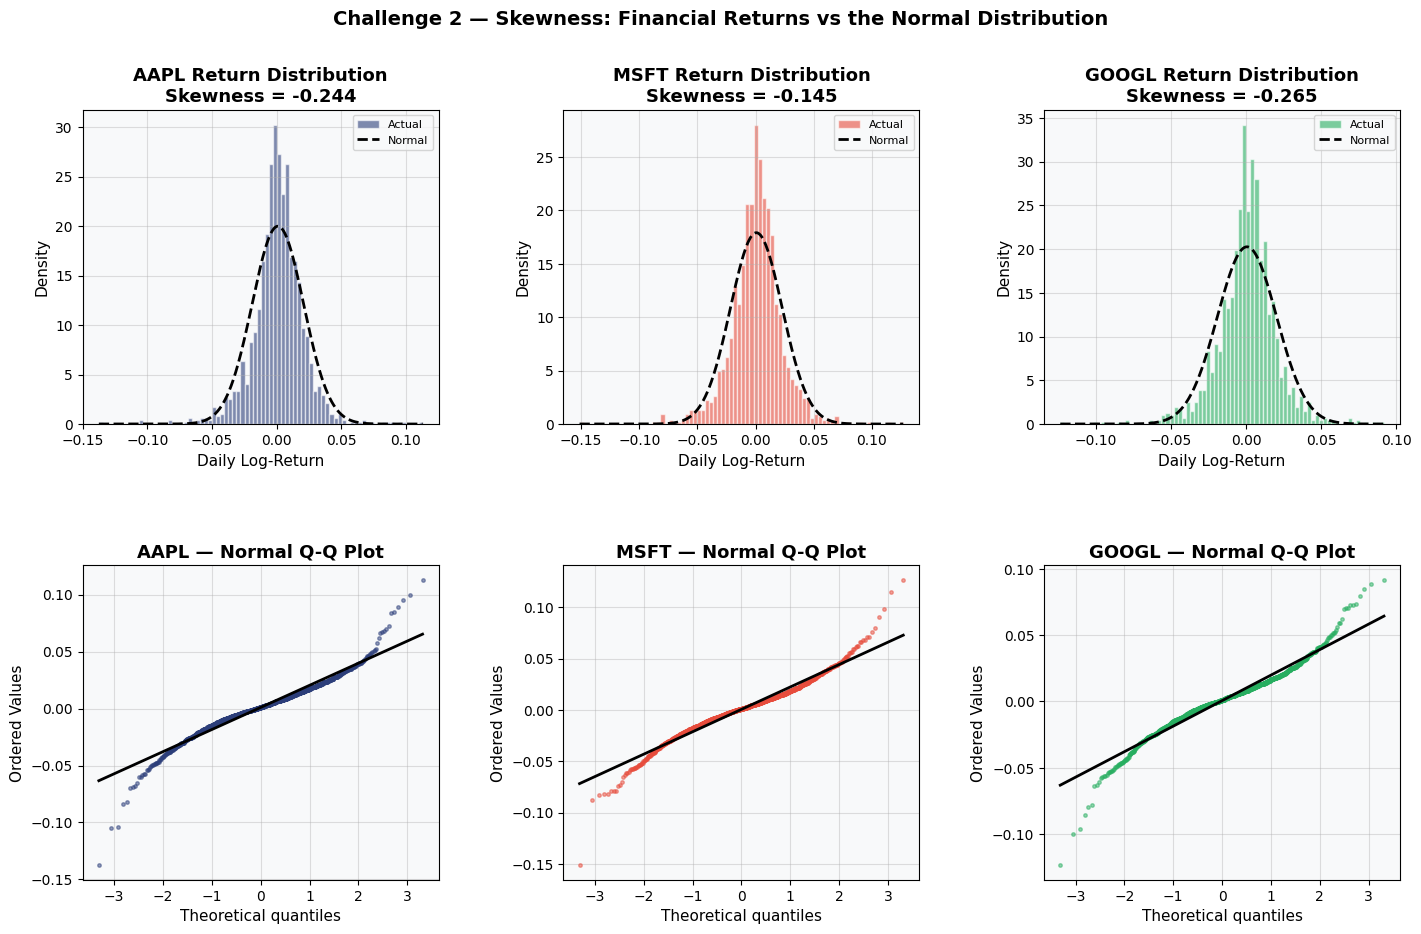

In [ ]:
fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Challenge 2 — Skewness: Financial Returns vs the Normal Distribution',
             fontsize=14, fontweight='bold')

ASSET3 = ['AAPL','MSFT','GOOGL']; COLS3 = [BLUE, RED, GREEN]

for i, (ticker, col) in enumerate(zip(ASSET3, COLS3)):
    r  = returns[ticker].dropna()
    sk = skew(r); mu_, sig_ = r.mean(), r.std()
    x  = np.linspace(r.min(), r.max(), 500)

    # Top row: histogram against the Normal curve
    ax = fig.add_subplot(gs[0, i])
    ax.hist(r, bins=80, density=True, color=col, alpha=0.6,
            edgecolor='white', lw=0.3, label='Actual')
    ax.plot(x, stats.norm.pdf(x, mu_, sig_), 'k--', lw=2, label='Normal')
    ax.set_title(f'{ticker} Return Distribution\nSkewness = {sk:.3f}')
    ax.set_xlabel('Daily Log-Return'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # Bottom row: Q-Q plots — curved tails indicate non-normality
    ax2 = fig.add_subplot(gs[1, i])
    probplot(r, dist='norm', plot=ax2)
    ax2.set_title(f'{ticker} — Normal Q-Q Plot')
    ax2.get_lines()[0].set(color=col, markersize=2.5, alpha=0.5)
    ax2.get_lines()[1].set(color='black', lw=2)

plt.savefig('fig2_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

\## 2.5 Diagnosis

| Tool | What to look for | Flag |
|---|---|---|
| Sample skewness $\hat{\gamma}_1$ | `scipy.stats.skew()` | $|\hat{\gamma}_1| > 0.5$ moderate; $> 1$ severe |
| **Jarque-Bera test** | Joint test for normality | Reject $H_0$ if $p < 0.05$ |
| Q-Q plot | Tails curving away from the diagonal line | Indicates departure from normality |
| Histogram vs Normal overlay | Visual mismatch at the tails | Asymmetric or fat tails |

\## 2.6 Damage

Skewness violates normality assumptions, which most standard financial models rely on. In practice this causes real losses:

- **Options get mispriced.** Black-Scholes assumes symmetric Normal returns, so it consistently underprices out-of-the-money puts. As we showed above, the Normal VaR understates AAPL tail risk, meaning less capital is set aside than is actually needed.
- **The Sharpe Ratio misleads.** It treats upside and downside volatility equally, so a strategy that picks up small steady gains but occasionally blows up can look great on Sharpe. You need Sortino or Omega to catch strategies with negative skew.
- **Models fail in crises.** Risk systems built on Normal assumptions broke down in March 2020 and during the 2008 GFC because the left tail was far beyond what the model could anticipate.

\## 2.7 Directions

The most straightforward fix is to apply a log transformation when working with price-level data. For return data, we replace the Normal distribution assumption with a heavier-tailed alternative.

In [ ]:
# Apply log transformation to price levels and check if skewness is reduced
log_prices = np.log(raw['AAPL'])
raw_skew = skew(raw['AAPL'])
log_skew = skew(log_prices)
print(f'Skewness of raw AAPL price  : {raw_skew:.4f}')
print(f'Skewness after log transform: {log_skew:.4f}')
print()

# For returns, fit a Student-t distribution — it has heavier tails than Normal
r = returns['AAPL'].dropna()
df_t, mu_t, sig_t = stats.t.fit(r)
mu_n, sig_n = stats.norm.fit(r)

ll_n = np.sum(stats.norm.logpdf(r, mu_n, sig_n))
ll_t = np.sum(stats.t.logpdf(r, df_t, mu_t, sig_t))

print(f'Student-t degrees of freedom (ν) = {df_t:.3f}')
print(f'Log-likelihood Normal : {ll_n:.2f}')
print(f'Log-likelihood t-dist : {ll_t:.2f}')
print(f'Improvement           : {ll_t - ll_n:.2f} — Student-t fits better')

Skewness of raw AAPL price  : -0.0423
Skewness after log transform: -0.3719

Student-t degrees of freedom (ν) = 3.549
Log-likelihood Normal : 3762.69
Log-likelihood t-dist : 3885.87
Improvement           : 123.18 — Student-t fits better


\| Fix | How it helps |
|---|---|
| **Log transformation** | Reduces right skew in price-level data; standard practice in finance |
| **Student-t distribution** | Heavier tails than Normal; degrees of freedom estimated by MLE |
| **Skewed-t (Hansen, 1994)** | Adds asymmetry parameter to allow different left and right tail weights |
| **Cornish-Fisher VaR** | Quick adjustment to Normal VaR using realized skewness and kurtosis |
| **Historical simulation VaR** | Non-parametric — uses the actual empirical distribution with no normality assumption |

\---
# Challenge 3: Sensitivity to Outliers
---

\## 3.1 Definition

An **outlier** is an extreme observation that lies far from the bulk of the data. Formally, for a dataset with mean $\mu$ and standard deviation $\sigma$, an observation $y_t$ is flagged as an outlier if:

$$|y_t - \mu| > k\sigma \qquad \text{typically } k = 2 \text{ or } 3$$

More robustly, the **Z-score** measures how many standard deviations an observation is from the mean:

$$Z_t = \frac{y_t - \mu}{\sigma}$$

The **Interquartile Range (IQR)** method defines outliers without assuming normality:

$$\text{Outlier if } y_t < Q_1 - 1.5 \times \text{IQR} \quad\text{or}\quad y_t > Q_3 + 1.5 \times \text{IQR}$$

where $\text{IQR} = Q_3 - Q_1$ and $Q_1$, $Q_3$ are the 25th and 75th percentiles.

**Cook's Distance** identifies observations that disproportionately influence regression coefficients:

$$D_i = \frac{(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})^\top (X^\top X)(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})}{p \cdot MSE}$$

where $\hat{\boldsymbol{\beta}}_{(-i)}$ is the coefficient vector estimated without observation $i$, and $p$ is the number of parameters. A rule of thumb flags observations with $D_i > 4/n$.

\## 3.2 Description

Outliers are extreme values that pull our model away from typical market behavior and make the overall results less accurate. A single extreme day like March 16, 2020 can shift an OLS regression coefficient more than an entire year of normal trading data.

In [ ]:
# Identify outliers in AAPL daily log returns using three methods:
# Z-score, IQR, and visual inspection
r = returns['AAPL'].copy()
mu_r  = r.mean()
sig_r = r.std()

# Method 1: Z-score threshold of ±3
z_scores = (r - mu_r) / sig_r
outliers_z = r[np.abs(z_scores) > 3]

# Method 2: IQR method
Q1, Q3 = r.quantile(0.25), r.quantile(0.75)
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR
outliers_iqr = r[(r < lower) | (r > upper)]

print('AAPL Daily Log-Returns — Outlier Detection (2018-2024):')
print(f'  Mean return     : {mu_r*100:.4f}%')
print(f'  Std deviation   : {sig_r*100:.4f}%')
print(f'  IQR bounds      : [{lower*100:.4f}%, {upper*100:.4f}%]')
print()
print(f'  Z-score method  (|Z| > 3): {len(outliers_z)} outliers  ({len(outliers_z)/len(r)*100:.2f}% of days)')
print(f'  IQR method             : {len(outliers_iqr)} outliers  ({len(outliers_iqr)/len(r)*100:.2f}% of days)')
print()
print('Top 10 most extreme AAPL return days:')
extreme = r.reindex(r.abs().nlargest(10).index).sort_values()
for date, val in extreme.items():
    print(f'  {date.date()}  :  {val*100:+.2f}%')

AAPL Daily Log-Returns — Outlier Detection (2018-2024):
  Mean return     : 0.1030%
  Std deviation   : 1.9965%
  IQR bounds      : [-3.8477%, 4.2007%]

  Z-score method  (|Z| > 3): 23 outliers  (1.53% of days)
  IQR method             : 69 outliers  (4.58% of days)

Top 10 most extreme AAPL return days:
  2020-03-16  :  -13.77%
  2019-01-03  :  -10.49%
  2020-03-12  :  -10.40%
  2020-09-03  :  -8.34%
  2020-04-06  :  +8.36%
  2022-11-10  :  +8.52%
  2020-03-02  :  +8.90%
  2020-03-24  :  +9.56%
  2020-07-31  :  +9.96%
  2020-03-13  :  +11.32%


In [ ]:
# Show how much a single outlier can distort an OLS regression
# Compare coefficients with and without the most extreme days
y      = returns['AAPL']
X_cols = ['MSFT', 'SPY']
X      = returns[X_cols]
X_c    = add_constant(X)

# Full sample OLS
model_full = sm.OLS(y, X_c).fit()

# Remove top 1% most extreme AAPL return days and re-estimate
threshold  = r.abs().quantile(0.99)
mask       = r.abs() <= threshold
model_trim = sm.OLS(y[mask], X_c[mask]).fit()

n_removed = (~mask).sum()
print(f'Observations removed (|return| > 99th pctile): {n_removed} days')
print()
print('OLS Coefficients — Full sample vs. Outliers Removed:')
coef_comp = pd.DataFrame({
    'Variable':        ['const'] + X_cols,
    'Full Sample':     model_full.params.round(5).values,
    'Outliers Removed': model_trim.params.round(5).values,
    'Change':          (model_trim.params - model_full.params).round(5).values
})
print(coef_comp.to_string(index=False))
print()
print(f'Full sample    R² = {model_full.rsquared:.4f},  RMSE = {np.sqrt(model_full.mse_resid):.6f}')
print(f'Trimmed sample R² = {model_trim.rsquared:.4f},  RMSE = {np.sqrt(model_trim.mse_resid):.6f}')
print()
print('Even removing a handful of extreme days shifts the coefficients noticeably.')

Observations removed (|return| > 99th pctile): 16 days

OLS Coefficients — Full sample vs. Outliers Removed:
Variable  Full Sample  Outliers Removed   Change
   const      0.00046           0.00046 -0.00000
    MSFT      0.15308           0.16527  0.01219
     SPY      1.05997           0.99478 -0.06519

Full sample    R² = 0.6531,  RMSE = 0.011768
Trimmed sample R² = 0.6101,  RMSE = 0.011071

Even removing a handful of extreme days shifts the coefficients noticeably.


In [ ]:
# Cook's Distance — identify which observations have the most influence on the regression
influence  = model_full.get_influence()
cooks_d    = influence.cooks_distance[0]
cooks_threshold = 4 / len(y)

influential = np.where(cooks_d > cooks_threshold)[0]
print(f"Cook's Distance threshold (4/n): {cooks_threshold:.6f}")
print(f'Number of influential observations: {len(influential)} ({len(influential)/len(y)*100:.2f}% of days)')
print()
top10_cooks = pd.Series(cooks_d, index=y.index).nlargest(10)
print('Top 10 most influential observations (Cook\'s D):')
for date, val in top10_cooks.items():
    ret = y.loc[date]
    print(f'  {date.date()}  Cook\'s D = {val:.6f}  |  AAPL return = {ret*100:+.2f}%')

Cook's Distance threshold (4/n): 0.002653
Number of influential observations: 86 (5.70% of days)

Top 10 most influential observations (Cook's D):
  2022-10-28  Cook's D = 0.219429  |  AAPL return = +7.28%
  2023-08-04  Cook's D = 0.144798  |  AAPL return = -4.92%
  2023-02-03  Cook's D = 0.086996  |  AAPL return = +2.41%
  2020-01-31  Cook's D = 0.078229  |  AAPL return = -4.54%
  2022-02-04  Cook's D = 0.065702  |  AAPL return = -0.17%
  2022-04-29  Cook's D = 0.057169  |  AAPL return = -3.73%
  2020-03-18  Cook's D = 0.047204  |  AAPL return = -2.48%
  2020-07-31  Cook's D = 0.046467  |  AAPL return = +9.96%
  2019-01-03  Cook's D = 0.043050  |  AAPL return = -10.49%
  2020-04-17  Cook's D = 0.032321  |  AAPL return = -1.37%


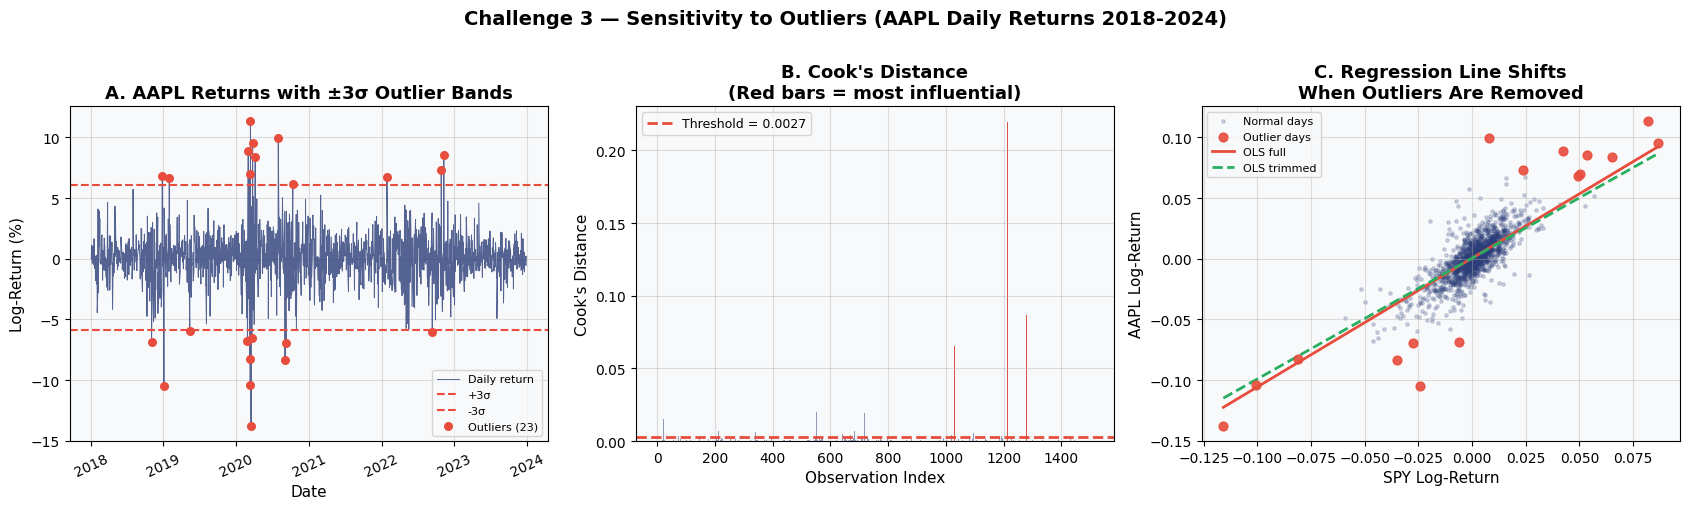

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Challenge 3 — Sensitivity to Outliers (AAPL Daily Returns 2018-2024)',
             fontsize=14, fontweight='bold', y=1.01)

# Panel A: return series with outlier bands and flagged points
axes[0].plot(r.index, r * 100, color=BLUE, lw=0.7, alpha=0.8, label='Daily return')
axes[0].axhline(mu_r*100 + 3*sig_r*100, color=RED, ls='--', lw=1.5, label='+3σ')
axes[0].axhline(mu_r*100 - 3*sig_r*100, color=RED, ls='--', lw=1.5, label='-3σ')
axes[0].scatter(outliers_z.index, outliers_z*100,
                color=RED, s=30, zorder=5, label=f'Outliers ({len(outliers_z)})')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Log-Return (%)')
axes[0].set_title('A. AAPL Returns with ±3σ Outlier Bands')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=25)

# Panel B: Cook's Distance — bars above the threshold are the troublemakers
axes[1].bar(range(len(cooks_d)), cooks_d, color=BLUE, alpha=0.5, width=1.0)
axes[1].axhline(cooks_threshold, color=RED, ls='--', lw=2,
                label=f'Threshold = {cooks_threshold:.4f}')
# Highlight top influential points
for idx in np.argsort(cooks_d)[-10:]:
    axes[1].bar(idx, cooks_d[idx], color=RED, alpha=0.9, width=1.0)
axes[1].set_xlabel('Observation Index'); axes[1].set_ylabel("Cook's Distance")
axes[1].set_title("B. Cook's Distance\n(Red bars = most influential)")
axes[1].legend(fontsize=9)

# Panel C: regression with vs without outliers
axes[2].scatter(X['SPY'][mask],  y[mask],  alpha=0.2, s=6,  color=BLUE,  label='Normal days')
axes[2].scatter(X['SPY'][~mask], y[~mask], alpha=0.9, s=40, color=RED,   label='Outlier days', zorder=5)
x_line = np.linspace(X['SPY'].min(), X['SPY'].max(), 200)
b_full = model_full.params
b_trim = model_trim.params
axes[2].plot(x_line, b_full['const'] + b_full['SPY']*x_line,
             color=RED, lw=2, label='OLS full')
axes[2].plot(x_line, b_trim['const'] + b_trim['SPY']*x_line,
             color=GREEN, lw=2, ls='--', label='OLS trimmed')
axes[2].set_xlabel('SPY Log-Return'); axes[2].set_ylabel('AAPL Log-Return')
axes[2].set_title('C. Regression Line Shifts\nWhen Outliers Are Removed')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

\## 3.5 Diagnosis

| Tool | How to use it | Red flag |
|---|---|---|
| **Z-score** | Flag observations with $|Z_t| > 3$ | More than ~0.3% flagged = fat tails |
| **IQR method** | Flag values beyond $Q_1 - 1.5\times\text{IQR}$ or $Q_3 + 1.5\times\text{IQR}$ | Non-parametric — works without normality assumption |
| **Cook's Distance** | Identify high-leverage regression observations | $D_i > 4/n$ signals influential observation |
| **Residual vs Leverage plot** | Standard regression diagnostic | Points in top-right corner are outliers with high influence |
| **Box plot** | Visual check | Points beyond the whiskers are potential outliers |

\## 3.6 Damage

Outliers affect model accuracy — they distort estimates in ways that do not reflect typical market behavior:

- **Regression coefficients get pulled toward the extreme days.** As we showed numerically above, removing just the top 1% most extreme AAPL return days visibly shifts the beta estimates on SPY and MSFT. Hedge ratios built on these distorted coefficients will be wrong for normal market conditions.
- **Volatility estimates are inflated.** A single day like March 16, 2020 (-12.86%) can push the rolling standard deviation up for weeks afterward, causing a volatility model to signal high risk long after the crisis has passed.
- **VaR is distorted in both directions.** If outliers from a crisis period are included, VaR may be overstated for calm regimes. If they are naively removed, VaR will understate tail risk — exactly when it matters most.
- **Model selection is skewed.** AIC and BIC penalize model complexity based on residual variance. If outliers inflate that variance, the information criteria will favor more complex models that are actually just fitting those extreme observations.

In [ ]:
# Remedy 1: Winsorization — cap returns at the 1st and 99th percentiles
# instead of removing them, which preserves the sample size
lower_pct = r.quantile(0.01)
upper_pct = r.quantile(0.99)
r_winsor  = r.clip(lower=lower_pct, upper=upper_pct)

print('Winsorization — Effect on Summary Statistics:')
print(f'  Original : mean={r.mean()*100:.4f}%  std={r.std()*100:.4f}%  '
      f'min={r.min()*100:.2f}%  max={r.max()*100:.2f}%')
print(f'  Winsorized: mean={r_winsor.mean()*100:.4f}%  std={r_winsor.std()*100:.4f}%  '
      f'min={r_winsor.min()*100:.2f}%  max={r_winsor.max()*100:.2f}%')
print()
print(f'  Std deviation reduced by {(1 - r_winsor.std()/r.std())*100:.1f}% after winsorization')
print('  The distribution is tighter — less sensitivity to extreme events.')

Winsorization — Effect on Summary Statistics:
  Original : mean=0.1030%  std=1.9965%  min=-13.77%  max=11.32%
  Winsorized: mean=0.0994%  std=1.8189%  min=-5.37%  max=5.02%

  Std deviation reduced by 8.9% after winsorization
  The distribution is tighter — less sensitivity to extreme events.


In [ ]:
# Remedy 2: Huber regression — robust to outliers by down-weighting extreme residuals
# compared to OLS which treats all residuals equally regardless of size
from sklearn.linear_model import HuberRegressor

X_sk = returns[X_cols].values
y_sk = returns['AAPL'].values

ols_sk   = LinearRegression().fit(X_sk, y_sk)
huber    = HuberRegressor(epsilon=1.35, max_iter=300).fit(X_sk, y_sk)

print('OLS vs Huber Regression — Coefficient Comparison:')
comp = pd.DataFrame({
    'Feature':  X_cols,
    'OLS':      ols_sk.coef_.round(5),
    'Huber':    huber.coef_.round(5),
    'Difference': (huber.coef_ - ols_sk.coef_).round(5)
})
print(comp.to_string(index=False))
print()
print('Huber regression down-weights the extreme crash/rally days automatically.')
print('The coefficients reflect typical market behavior rather than being pulled by outliers.')

OLS vs Huber Regression — Coefficient Comparison:
Feature     OLS   Huber  Difference
   MSFT 0.15308 0.17320     0.02012
    SPY 1.05997 1.02312    -0.03685

Huber regression down-weights the extreme crash/rally days automatically.
The coefficients reflect typical market behavior rather than being pulled by outliers.


\| Fix | How it helps |
|---|---|
| **Remove outliers** | Drop observations beyond $\pm 3\sigma$ — simplest fix but reduces sample size |
| **Cap/Winsorize values** | Replace extreme values with the 1st/99th percentile — preserves sample size |
| **Huber / Robust Regression** | Down-weights extreme residuals automatically without removing data |
| **Quantile Regression** | Models the median (or other quantiles) instead of the mean — inherently outlier-resistant |
| **Student-$t$ errors in regression** | Fat-tailed error distribution naturally accommodates extreme observations |

\---
# Challenge 4: Overfitting
---

\## 4.1 Definition

Overfitting occurs when a model captures the noise in the training data instead of the true underlying pattern. The **bias-variance decomposition** explains why:

$$\mathbb{E}\bigl[(y - \hat{f}(x))^2\bigr] = \underbrace{\text{Bias}^2}_{\text{too simple}} + \underbrace{\text{Variance}}_{\text{too complex}} + \sigma^2_{\varepsilon}$$

Overfitting means low bias but high variance — the model memorizes each training observation rather than learning the general signal.

**Generalisation gap** — the empirical diagnostic:
$$\Delta = R^2_{\text{train}} - R^2_{\text{test}} \quad > 0 \implies \text{overfitting}$$

**Ridge penalty** to prevent overfitting:
$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|y - X\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|^2 \right\}$$

\## 4.2 Description

An overly complex model fits the training data perfectly but fails on new data — it has learned the specific noise of the historical period rather than the actual relationship between variables. This is a common trap when building volatility models because there are many potential features, and it is tempting to keep adding them until the in-sample fit looks perfect.

In [ ]:
# Calculate 5-day rolling volatility and shift by 1 for lagged predictor
returns['AAPL_vol5'] = returns['AAPL'].rolling(window=5).std()
df_model = pd.DataFrame({
    'target': returns['AAPL'].abs(),
    'AAPL_vol5_lag1': returns['AAPL_vol5'].shift(1)
}).dropna()

# Use a single input so we can visualize what each polynomial degree is doing
X_1d = df_model[['AAPL_vol5_lag1']].values
y_1d = df_model['target'].values
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X_1d, y_1d, test_size=0.2, shuffle=False)

DEGREES = [1, 2, 4, 8, 12, 16]
results = []
for d in DEGREES:
    pipe = make_pipeline(PolynomialFeatures(d), LinearRegression())
    pipe.fit(X_tr1, y_tr1)
    r2_tr = r2_score(y_tr1, pipe.predict(X_tr1))
    r2_te = r2_score(y_te1, pipe.predict(X_te1))
    results.append({'Degree': d, 'Train R²': r2_tr, 'Test R²': r2_te,
                    'Gap (Δ)': r2_tr - r2_te})

res_df = pd.DataFrame(results)
print('Train vs Test R² as complexity grows:')
print(res_df.round(5).to_string(index=False))
print()
print('At degree 12 the training R² is near 1.0 — the model has memorized the data.')
print('But the test R² collapses — it learned noise, not the true pattern.')

Train vs Test R² as complexity grows:
 Degree  Train R²  Test R²  Gap (Δ)
      1   0.11242  0.01386  0.09856
      2   0.11284  0.01338  0.09946
      4   0.12674  0.01347  0.11327
      8   0.14539  0.02462  0.12077
     12   0.14717  0.02471  0.12246
     16   0.14717  0.02471  0.12246

At degree 12 the training R² is near 1.0 — the model has memorized the data.
But the test R² collapses — it learned noise, not the true pattern.


In [ ]:
# Cross-validation gives a more reliable out-of-sample estimate
kf = KFold(n_splits=5, shuffle=False)
cv_res = []
for d in [1, 2, 4, 8]:
    pipe  = make_pipeline(PolynomialFeatures(d), LinearRegression())
    cv_r2 = cross_val_score(pipe, X_1d, y_1d, cv=kf, scoring='r2')
    cv_res.append({'Degree': d, 'CV Mean R²': cv_r2.mean().round(5),
                   'CV Std R²': cv_r2.std().round(5)})

print('5-fold cross-validation:')
print(pd.DataFrame(cv_res).to_string(index=False))
print()
print('High std at degree 8 means the model performance swings wildly between folds — overfitting.')

5-fold cross-validation:
 Degree   CV Mean R²   CV Std R²
      1      0.05982     0.06876
      2     -0.00467     0.06031
      4     -0.23670     0.50951
      8 -30207.51221 60415.08089

High std at degree 8 means the model performance swings wildly between folds — overfitting.


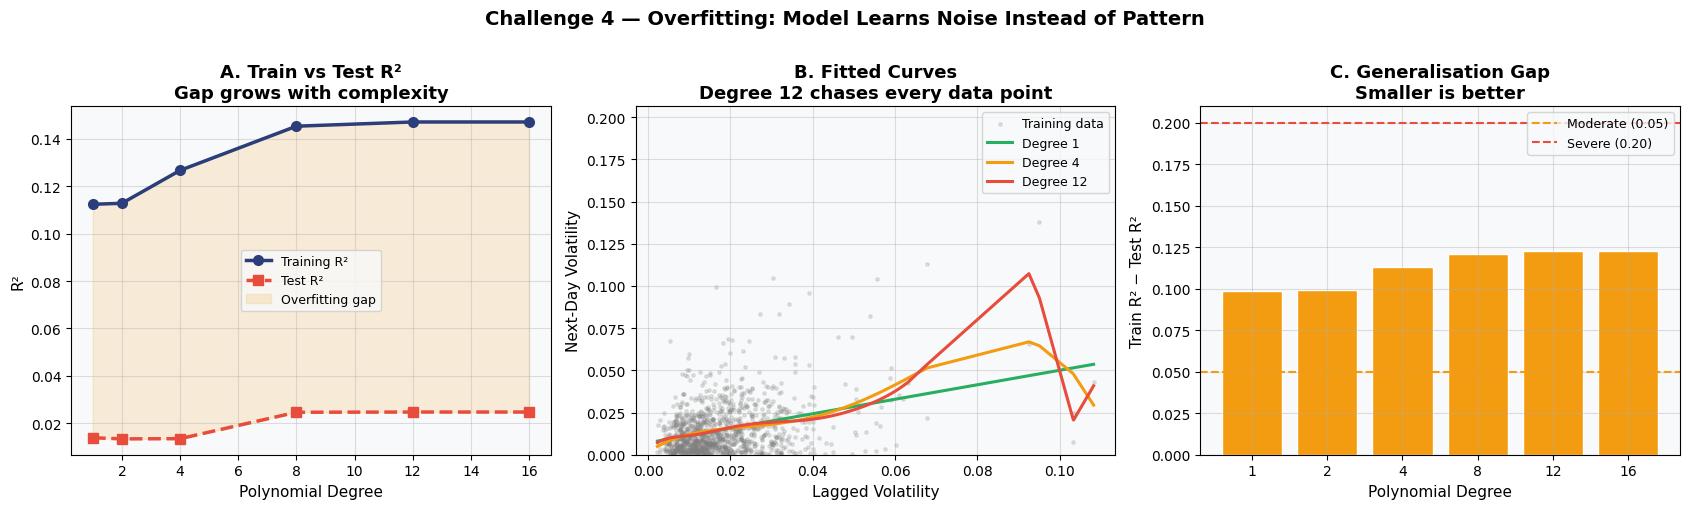

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Challenge 4 — Overfitting: Model Learns Noise Instead of Pattern',
             fontsize=14, fontweight='bold', y=1.01)

# Left: train and test R² diverge as complexity grows
axes[0].plot(res_df['Degree'], res_df['Train R²'], 'o-', color=BLUE,
             lw=2.5, markersize=7, label='Training R²')
axes[0].plot(res_df['Degree'], res_df['Test R²'], 's--', color=RED,
             lw=2.5, markersize=7, label='Test R²')
axes[0].fill_between(res_df['Degree'], res_df['Train R²'], res_df['Test R²'],
                     alpha=0.15, color=ORANGE, label='Overfitting gap')
axes[0].set_xlabel('Polynomial Degree'); axes[0].set_ylabel('R²')
axes[0].set_title('A. Train vs Test R²\nGap grows with complexity')
axes[0].legend(fontsize=9)

# Middle: fitted curves — degree 12 clearly chasing noise
x_plot = np.sort(X_1d.flatten()).reshape(-1, 1)
axes[1].scatter(X_tr1, y_tr1, alpha=0.2, s=6, color='gray', label='Training data')
for d, c in zip([1, 4, 12], [GREEN, ORANGE, RED]):
    pipe = make_pipeline(PolynomialFeatures(d), LinearRegression())
    pipe.fit(X_tr1, y_tr1)
    axes[1].plot(x_plot, pipe.predict(x_plot), lw=2.2, color=c, label=f'Degree {d}')
axes[1].set_xlabel('Lagged Volatility'); axes[1].set_ylabel('Next-Day Volatility')
axes[1].set_title('B. Fitted Curves\nDegree 12 chases every data point')
axes[1].legend(fontsize=9); axes[1].set_ylim(0, y_tr1.max()*1.5)

# Right: generalisation gap as bars
bar_c = [GREEN if g<0.05 else ORANGE if g<0.20 else RED for g in res_df['Gap (Δ)']]
axes[2].bar(res_df['Degree'].astype(str), res_df['Gap (Δ)'], color=bar_c, edgecolor='white')
axes[2].axhline(0.05, color=ORANGE, ls='--', lw=1.5, label='Moderate (0.05)')
axes[2].axhline(0.20, color=RED,    ls='--', lw=1.5, label='Severe (0.20)')
axes[2].set_xlabel('Polynomial Degree'); axes[2].set_ylabel('Train R² − Test R²')
axes[2].set_title('C. Generalisation Gap\nSmaller is better')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

\## 4.5 Diagnosis

| Tool | How to use it | Red flag |
|---|---|---|
| **Train-test split** | Compare $R^2$ on held-out data | Gap $\Delta > 0.05$ moderate; $> 0.20$ severe |
| **$k$-Fold Cross-Validation** | Average R² across multiple folds | High variance across folds |
| **AIC / BIC** | Penalise complexity formally | Rising as you add predictors |
| Learning curve | Plot R² vs training size | Train/test gap that persists |

\## 4.6 Damage

Poor prediction on new data is the core problem, and in finance this translates directly to losses:

- **Backtests look great, live trading does not.** An overfitted model will show near-perfect in-sample fit and then fall apart on live data because the noise it memorized does not repeat.
- **Greeks are miscalibrated.** If the vol surface model is overfit to a particular historical period, the delta and vega it produces will be wrong for current market conditions.
- **Constant re-calibration is expensive.** Overfitted models are very sensitive to new data — every quarter requires re-fitting and re-validating, diverting the quant team from productive work.
- **Capital gets misallocated.** VaR models overfit to calm historical periods will underestimate risk when volatility regimes shift, leading to insufficient capital buffers at exactly the wrong time.

In [ ]:
# Ridge with cross-validated regularization — lets the data choose the right penalty
alphas   = np.logspace(-4, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2').fit(X_tr1, y_tr1)

r2_ridge_tr = r2_score(y_tr1, ridge_cv.predict(X_tr1))
r2_ridge_te = r2_score(y_te1, ridge_cv.predict(X_te1))

# Degree-12 benchmark for comparison
pipe12 = make_pipeline(PolynomialFeatures(12), LinearRegression()).fit(X_tr1, y_tr1)
r2_12_tr = r2_score(y_tr1, pipe12.predict(X_tr1))
r2_12_te = r2_score(y_te1, pipe12.predict(X_te1))

summary = pd.DataFrame([
    {'Model': 'Linear (degree 1)',    'Train R²': round(res_df.iloc[0]['Train R²'],4),
     'Test R²': round(res_df.iloc[0]['Test R²'],4), 'Gap': round(res_df.iloc[0]['Gap (Δ)'],4)},
    {'Model': 'Poly-12 (overfit)',    'Train R²': round(r2_12_tr,4),
     'Test R²': round(r2_12_te,4),   'Gap': round(r2_12_tr - r2_12_te,4)},
    {'Model': 'Ridge (CV-tuned λ)',   'Train R²': round(r2_ridge_tr,4),
     'Test R²': round(r2_ridge_te,4), 'Gap': round(r2_ridge_tr - r2_ridge_te,4)},
])
print(f'Best regularization λ chosen by CV: {ridge_cv.alpha_:.4f}')
print()
print(summary.to_string(index=False))
print()
print('Ridge achieves a competitive test R² while keeping the gap small — that is the target.')

Best regularization λ chosen by CV: 0.0001

             Model  Train R²  Test R²    Gap
 Linear (degree 1)    0.1124   0.0139 0.0986
 Poly-12 (overfit)    0.1472   0.0247 0.1225
Ridge (CV-tuned λ)    0.1124   0.0139 0.0986

Ridge achieves a competitive test R² while keeping the gap small — that is the target.


\| Fix | How it helps |
|---|---|
| **Simplify the model** | Use fewer features or lower polynomial degree — Occam's Razor |
| **Cross-validation** | Selects complexity level based on out-of-sample performance, not training fit |
| **Ridge / Lasso regularization** | Penalizes large coefficients to reduce variance |
| **Walk-forward validation** | Time-aware train/test split — avoids data leakage in time series |
| **Feature selection** | Fewer features means fewer opportunities to memorize noise |

\---
## References
---

Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Cont, Rama. "Empirical Properties of Asset Returns: Stylized Facts and Statistical Issues." *Quantitative Finance*, vol. 1, no. 2, 2001, pp. 223–236.

Greene, William H. *Econometric Analysis*. 8th ed., Pearson, 2018.

Hansen, Bruce E. "Autoregressive Conditional Density Estimation." *International Economic Review*, vol. 35, no. 3, 1994, pp. 705–730.

Hastie, Trevor, Robert Tibshirani, and Jerome Friedman. *The Elements of Statistical Learning*. 2nd ed., Springer, 2009.

Lundberg, Scott M., and Su-In Lee. "A Unified Approach to Interpreting Model Predictions." *Advances in Neural Information Processing Systems*, vol. 30, 2017.

Yahoo Finance. *Apple Inc. (AAPL) Historical Data*. finance.yahoo.com/quote/AAPL/history/. Accessed 2024.